# Lancoz Algorithm, Ground-State: J1-J2

> **Code basé sur le tutoriel officiel de NetKet :**
> G. Carleo et F. Vicentini, *Ground-State: J1-J2 model*, NetKet Tutorials. 
> [En ligne]. Disponible : [https://netket.readthedocs.io/en/latest/tutorials/gs-j1j2.html](https://netket.readthedocs.io/en/latest/tutorials/gs-j1j2.html)

In [1]:
import jax 
jax.config.update("jax_enable_x64", True)
import tqdm as tqdm
import netket as nk
import time
import numpy as np
from tqdm import tqdm
import os
import networkx as nx
import matplotlib.pyplot as plt
import json
import jax.numpy as jnp
import sys

/Users/user/Desktop/EPFL/MA2/TPIV/project-tp/.env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

In [14]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.lancoz_alpha_opt import lanczos_ansatz, _logpsi_lanczos
from src.utils import *
from src.ener_landscape import *
from src.plot.plotlib import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
verbose = True

## The Frustrated $J_1-J_2$ Heisenberg Model

To introduce geometric frustration and test the robustness of our Neural Network Quantum State (NQS) alongside the Lanczos method, we investigate the $J_1-J_2$ Heisenberg model on a one-dimensional chain with periodic boundary conditions. 

Unlike the standard Heisenberg model, this system includes a next-nearest-neighbor interaction. The Hamiltonian of the model is given by:

$$H = J_1 \sum_{i=1}^{L} \boldsymbol{\sigma}_i \cdot \boldsymbol{\sigma}_{i+1} + J_2 \sum_{i=1}^{L} \boldsymbol{\sigma}_i \cdot \boldsymbol{\sigma}_{i+2}$$

where:
* $L$ is the number of sites in the 1D chain.
* $\boldsymbol{\sigma}_i = (\sigma_i^x, \sigma_i^y, \sigma_i^z)$ is the vector of Pauli matrices acting on site $i$.
* $J_1$ is the nearest-neighbor coupling constant.
* $J_2$ is the next-nearest-neighbor coupling constant.

The competition between the $J_1$ and $J_2$ interactions (specifically when both are antiferromagnetic, $J_1, J_2 > 0$) introduces strong quantum frustration, destroying simple magnetic orders and giving rise to highly entangled, complex quantum phases.

*(Note: We will apply a prefactor of $0.25$ in our code to smoothly transition from the Pauli matrix formalism to the physical spin-$1/2$ operators, $\mathbf{S} = \frac{1}{2}\boldsymbol{\sigma}$.)*

In [4]:
# Couplings J1 and J2
J2_J1 = 0.0
J = [1, J2_J1]
L = 20

# hyperparameters 
diag_shift = 1e-4           # The diagonal regularization parameter
learning_rate = 1e-2        # learning rate
n_samples = 4096            # number of samples (aug : pour avoir des stats physiques), 4096
n_iter = 100                # number of iterations # 600
alpha = 1                   # feature density. Number of features equal to alpha * input.shape[-1]
num_it = 100                # number of iterations for stats

# data directory
data_file = f"./datas/J1_J2/datas_alpha_J1_J2_{J2_J1}_iter_{n_iter}"
dir_init = data_file + "/RBM_init"

# hyperparameters for the alpha optimization
lr_alpha = 1e-2                         # learning rate for the alpha optimization
n_iter_alpha = 300                      # number of iterations for the alpha optimization
dir_alpha = data_file + "/RBM_alpha"    # directory to save the results of the alpha optimization
alpha_init = 0.5 + 0.0j                 # feature density for the initial RBM ansatz
num_it = 1000                           # number of iterations for the lanczos ansatz

if not os.path.exists(data_file):
    os.makedirs(data_file)
    print(f"Le dossier '{data_file}' vient d'être créé.")
else:
    print(f"Le dossier '{data_file}' existe déjà.")

if verbose :
    print(f" -> diag_shift : {diag_shift}")
    print(f" -> learning rate : {learning_rate}")
    print(f" -> # samples : {n_samples}")
    print(f" -> # iterations : {n_iter}")
    print(f" -> feature density : {alpha}")

hyperparameters = {
    "data_file": data_file,
    "dir_init": dir_init,
    "diag_shift": diag_shift,
    "learning_rate": learning_rate,
    "n_samples": n_samples,
    "n_iter": n_iter,
    "feature_density_alpha": alpha,
    "num_it": num_it,
    "J2/J1": J2_J1,
    "L": L
}
json_path = os.path.join(data_file, "hyperparameters.json")

with open(json_path, 'w') as f:
    json.dump(hyperparameters, f, indent=4) 

print(f"Paramètres sauvegardés avec succès dans {json_path}")

Le dossier './datas/datas_alpha_J1_J2_0.0_iter_100' existe déjà.
 -> diag_shift : 0.0001
 -> learning rate : 0.01
 -> # samples : 4096
 -> # iterations : 100
 -> feature density : 1
Paramètres sauvegardés avec succès dans ./datas/datas_alpha_J1_J2_0.0_iter_100/hyperparameters.json


In [5]:
# Define custom graph
edge_colors = []
for i in range(L):
    edge_colors.append([i, (i + 1) % L, 1])
    edge_colors.append([i, (i + 2) % L, 2])

# Define the netket graph object
graph = nk.graph.Graph(edges=edge_colors)

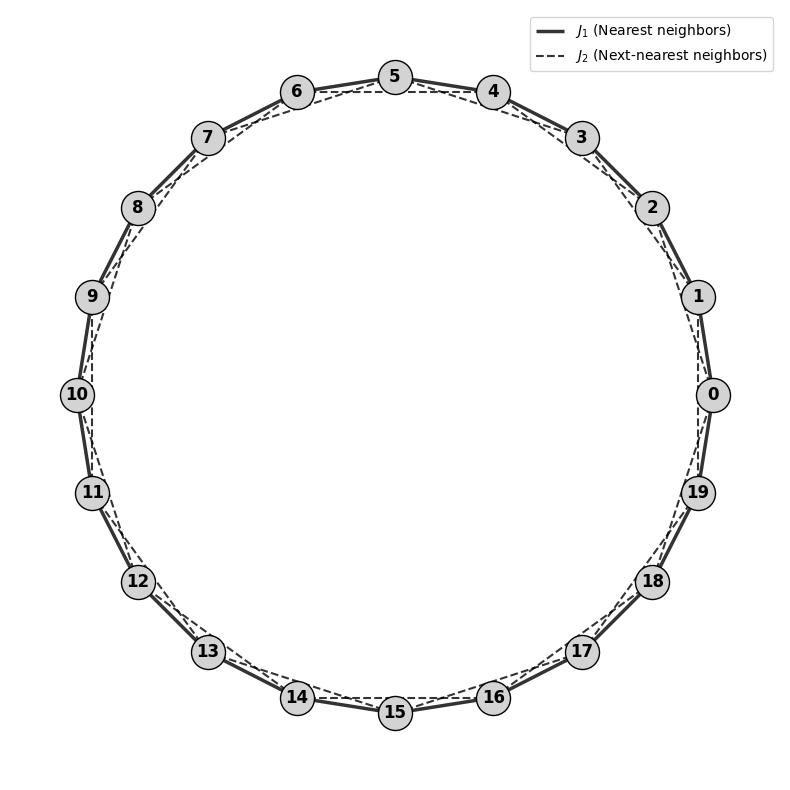

In [6]:
if verbose:
    nx_g = graph.to_networkx()
    pos = nx.circular_layout(nx_g)

    edges_j1 = [(u, v) for u, v, d in nx_g.edges(data=True) if d['color'] == 1]
    edges_j2 = [(u, v) for u, v, d in nx_g.edges(data=True) if d['color'] == 2]

    plt.figure(figsize=(8, 8))
    nx.draw_networkx_nodes(nx_g, pos, node_size=600, node_color='lightgray', edgecolors='black')
    nx.draw_networkx_labels(nx_g, pos, font_weight='bold')
    nx.draw_networkx_edges(
        nx_g, 
        pos, 
        edgelist=edges_j1, 
        width=2.5, 
        alpha=0.8, 
        label='$J_1$ (Nearest neighbors)'
    )
    nx.draw_networkx_edges(
        nx_g, 
        pos, 
        edgelist=edges_j2, 
        width=1.5, 
        alpha=0.8, 
        style='dashed', 
        label='$J_2$ (Next-nearest neighbors)'
    )
    # plt.title(f"Topologie du Modèle $J_1-J_2$ (L={L}, Conditions Périodiques)", fontsize=14, fontweight='bold')
    plt.legend(loc="upper right")
    plt.axis('off') 
    plt.tight_layout()
    plt.savefig("./assets/graph_J1J2.png", dpi=300)
    plt.show()

In [7]:
# Sigma^z*Sigma^z interactions
sigmaz = [[1, 0], [0, -1]]
mszsz = np.kron(sigmaz, sigmaz)

# Exchange interactions
exchange = np.asarray([[0, 0, 0, 0], [0, 0, 2, 0], [0, 2, 0, 0], [0, 0, 0, 0]])

bond_operator = [
    (J[0] * mszsz).tolist(),
    (J[1] * mszsz).tolist(),
    (-J[0] * exchange).tolist(),
    (J[1] * exchange).tolist(),
]

bond_color = [1, 2, 1, 2]

In [8]:
# Defining the Hamiltonian
hi = nk.hilbert.Spin(s=0.5, total_sz=0.0, N=graph.n_nodes) # Spin based Hilbert Space
ha = 0.25 * nk.operator.GraphOperator(
    hi, graph=graph, bond_ops=bond_operator, bond_ops_colors=bond_color
)

In [9]:
# Exact Diagonalization
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print("The exact ground-state energy is E0=", exact_gs_energy)

The exact ground-state energy is E0= -8.904386529876431


In [10]:
# Learning with a Restricted Boltzmann Machine (RBM)
model = nk.models.RBM(alpha=alpha, param_dtype=np.complex128)
sampler = nk.sampler.MetropolisExchange(hilbert=hi, graph=graph)
optimizer = nk.optimizer.Sgd(learning_rate=learning_rate)
vs_init = nk.vqs.MCState(sampler, model, n_samples=n_samples)
gs = nk.driver.VMC_SR(
    hamiltonian=ha, 
    optimizer=optimizer, 
    diag_shift=diag_shift, 
    variational_state=vs_init
)

gs.run(out=data_file + "/VMC_datas", n_iter=n_iter)

Automatic SR implementation choice:  QGT


100%|██████████| 100/100 [00:35<00:00,  2.79it/s, Energy=-8.8766-0.0001j ± 0.0033 [σ²=2.8e-02, R̂=1.004]]


(JsonLog('./datas/datas_alpha_J1_J2_0.0_iter_100/VMC_datas', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.06239056587219238
   	Params: 0.04313397407531738,)

✅ Figure saved as ./datas/datas_alpha_J1_J2_0.0_iter_100/RBM_energy_convergence.png


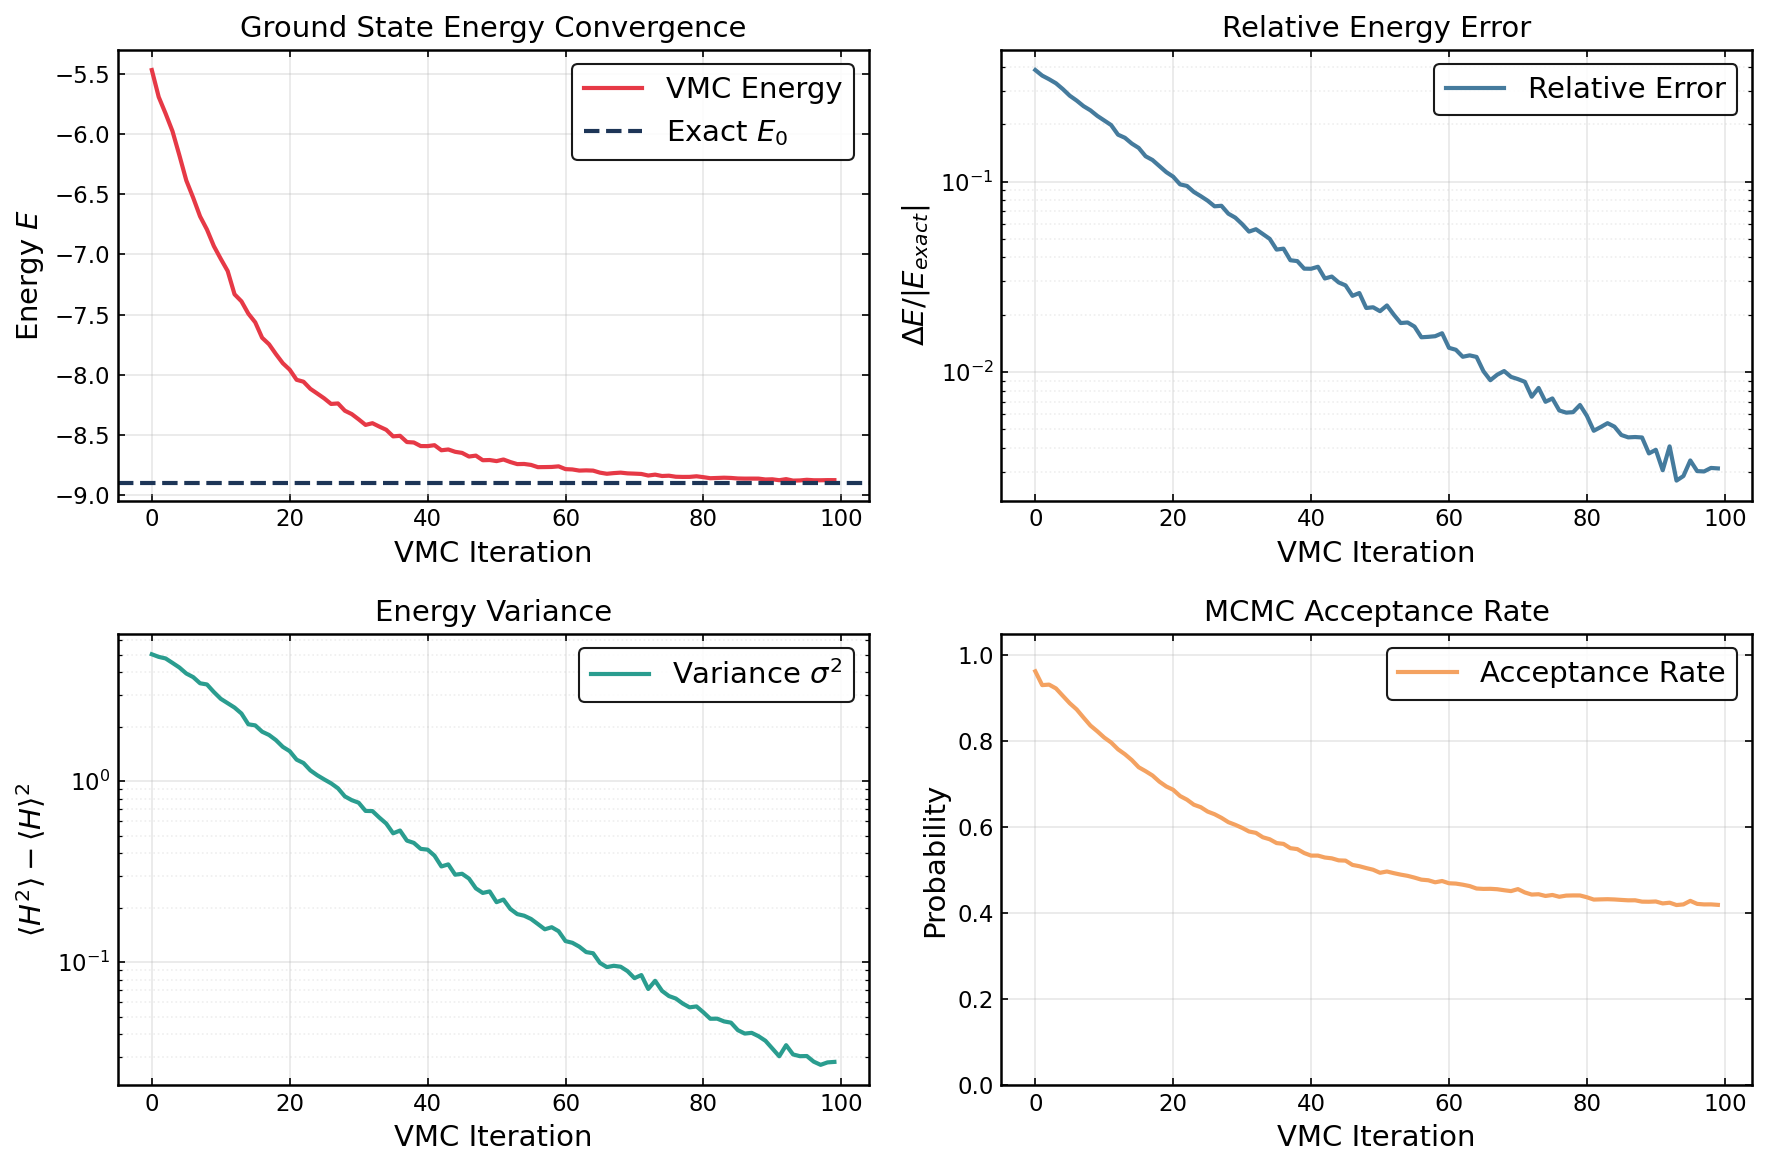

True

In [11]:
plot_VMC(
    data_file + "/VMC_datas.log", 
    exact_gs_energy, 
    save_fig=True, 
    fig_name=f"{data_file}/RBM_energy_convergence.png"
)

Resolution of the alpha point under study: 0.00035


MCMC Sampling & Reweighting: 100%|██████████| 2000/2000 [32:44<00:00,  1.02it/s]



Running Robust Moving-Average Bootstrap for Error Estimation...


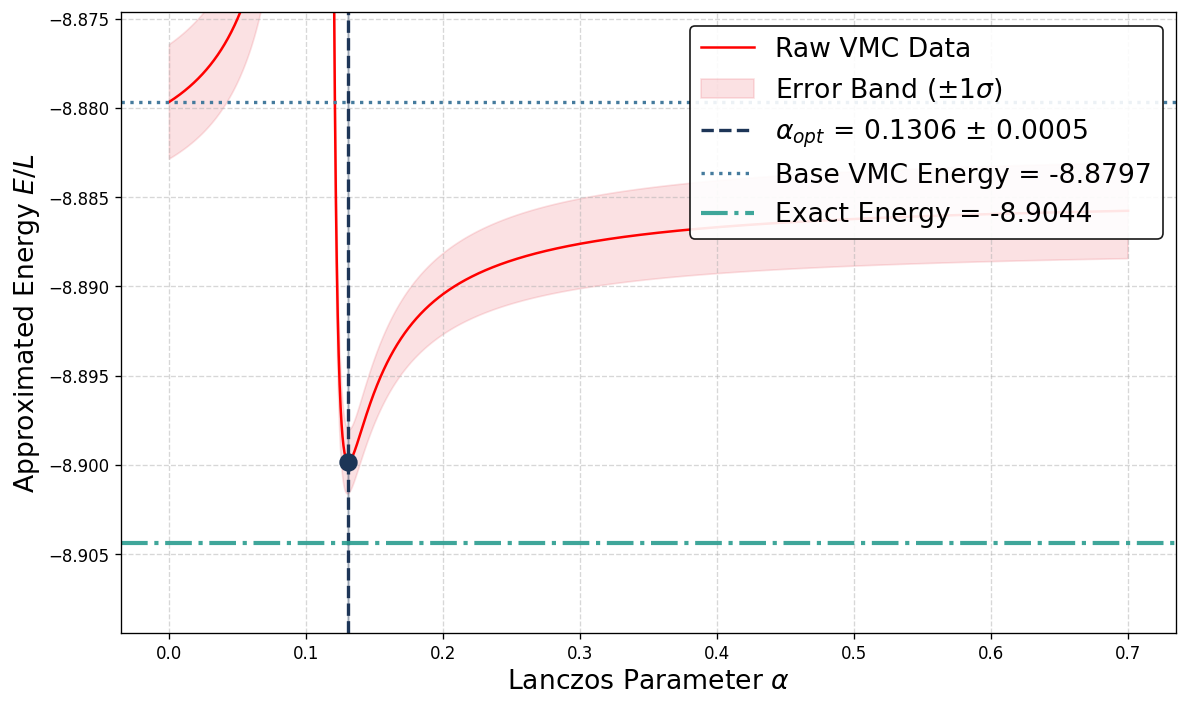

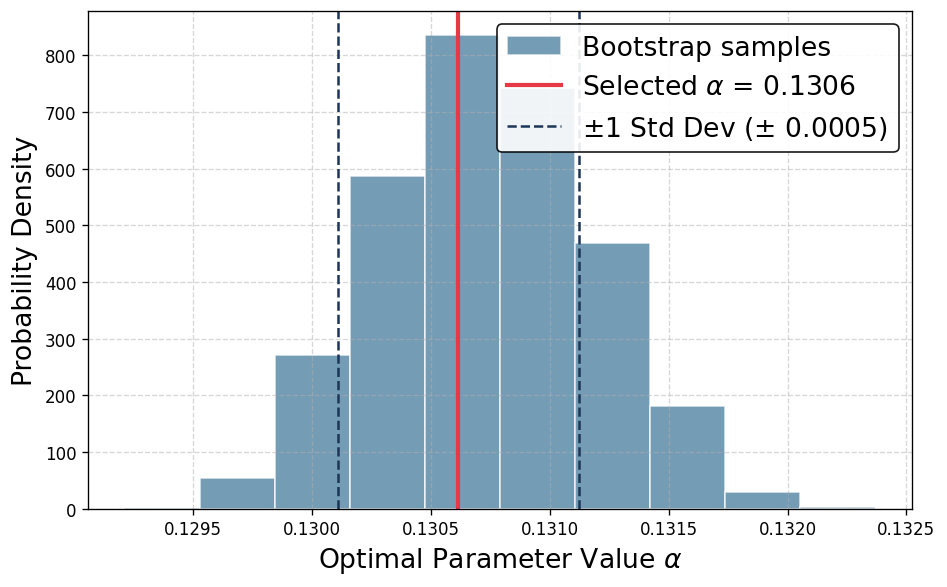

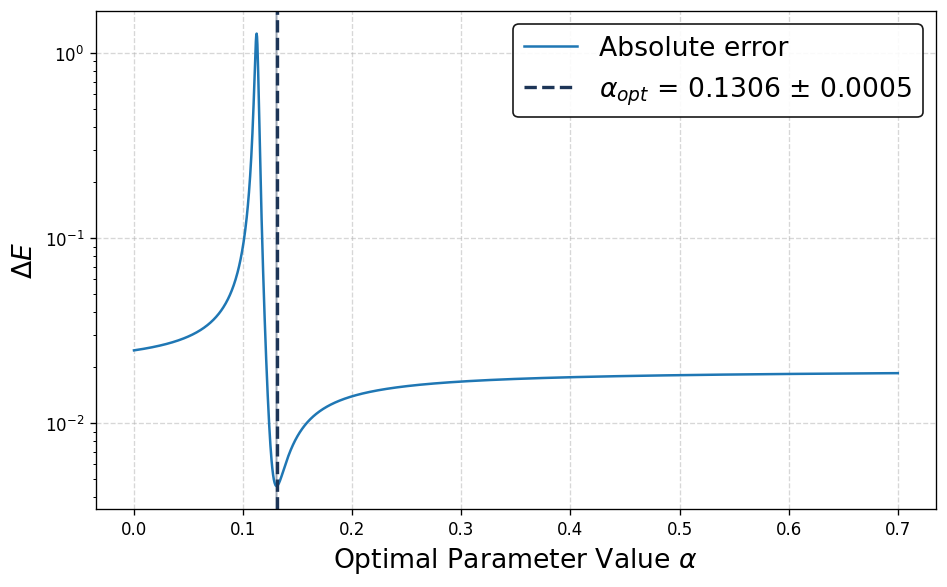


➔ EXACT MA ALPHA  : 0.13062 ± 0.00051
➔ ENERGY GAIN     : 0.02016 (VMC: -8.8797 ➔ Lanczos: -8.8998)


In [12]:
# --- Hyperparamètres ---
h2 = ha @ ha
alphas_to_test = np.linspace(0.0, 0.7, 2000)
N_MCMC_STEPS = 2000
N_BOOTSTRAP = 10000
SAVE_DIRECTORY = "./assets"

print(f"Resolution of the alpha point under study: {0.7 / N_MCMC_STEPS}")

energies_mean, energies_std, e_vmc = compute_lanczos_landscape(
    vs_init=vs_init, 
    ha=ha, 
    h2=h2, 
    alphas_to_test=alphas_to_test, 
    n_mcmc_steps=N_MCMC_STEPS
)

bootstrap_results = extract_optimal_alpha_bootstrap(
    alphas_to_test=alphas_to_test, 
    energies_mean=energies_mean, 
    energies_std=energies_std, 
    n_mcmc_steps=N_MCMC_STEPS,
    n_bootstrap=N_BOOTSTRAP
)

plot_lanczos_results(
    alphas_to_test=alphas_to_test, 
    energies_mean=energies_mean, 
    energies_std=energies_std, 
    e_vmc=e_vmc, 
    exact_gs_energy=exact_gs_energy, 
    bootstrap_results=bootstrap_results, 
    save_dir=SAVE_DIRECTORY
)

In [15]:
afun_original = lambda x: vs_init._apply_fun(vs_init.variables, x) # Figer l'ancienne RBM (Le monde statique)

lanczos_model = lanczos_ansatz(alpha_init=alpha_init, dtype=jnp.complex128)

dummy_logpsi = jnp.zeros((1,), dtype=jnp.complex128)
dummy_eloc = jnp.zeros((1,), dtype=jnp.complex128) # donnee manequin pour init eloc (jutse donner la taille)
# Bonne pratique JAX : utiliser jnp.empty au lieu de jnp.zeros si on ne se sert 
# que de la "shape" et du "dtype", ça évite une allocation mémoire inutile.
key = jax.random.PRNGKey(0)
lanczos_variables = lanczos_model.init(key, dummy_logpsi, dummy_eloc) # # lanczos_variables contient UNIQUEMENT {'params': {'alpha': 0.01}}

apply_lanczos = nk.jax.HashablePartial(
    _logpsi_lanczos, afun_original, ha
    )

vstate_lanczos = nk.vqs.MCState(
    sampler=vs_init.sampler,
    apply_fun=apply_lanczos,
    n_samples=vs_init.n_samples,
    variables=lanczos_variables, 
    n_discard_per_chain=vs_init.n_discard_per_chain, # Nombre d'échantillons à jeter par chaîne (thermalisation)
)

print("Variables de l'état :", vstate_lanczos.variables)

def track_alpha(step, log_data, driver):
    """
    Cette fonction est appelée par NetKet à CHAQUE itération.
    - step : le numéro de l'itération
    - driver : l'objet VMC qui contient tout notre état
    """
    valeur_alpha = driver.state.variables['params']['alpha']
    alpha_reel = valeur_alpha.real.item()
    historique_alpha.append(alpha_reel)
    
    return True

optimizer = nk.optimizer.Sgd(learning_rate=lr_alpha)
# optimizer = nk.optimizer.Adam(learning_rate=lr_alpha)
historique_alpha = []
gs = nk.driver.VMC_SR(
    hamiltonian=ha, 
    optimizer=optimizer, 
    diag_shift=False, 
    variational_state=vstate_lanczos
)
gs.run(n_iter=n_iter_alpha, out= dir_alpha, callback=track_alpha)

Variables de l'état : {'params': {'alpha': Array([0.5+0.j], dtype=complex128)}}
Automatic SR implementation choice:  QGT


100%|██████████| 300/300 [10:21<00:00,  2.07s/it, Energy=-8.8993+0.0005j ± 0.0020 [σ²=1.4e-02, R̂=1.002]]


(JsonLog('./datas/datas_alpha_J1_J2_0.0_iter_100/RBM_alpha', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.21156907081604004
   	Params: 0.11001849174499512,)

 -> Énergie moeynne Lancoz           : -8.898508
 -> Énergie exacte                   : -8.904387


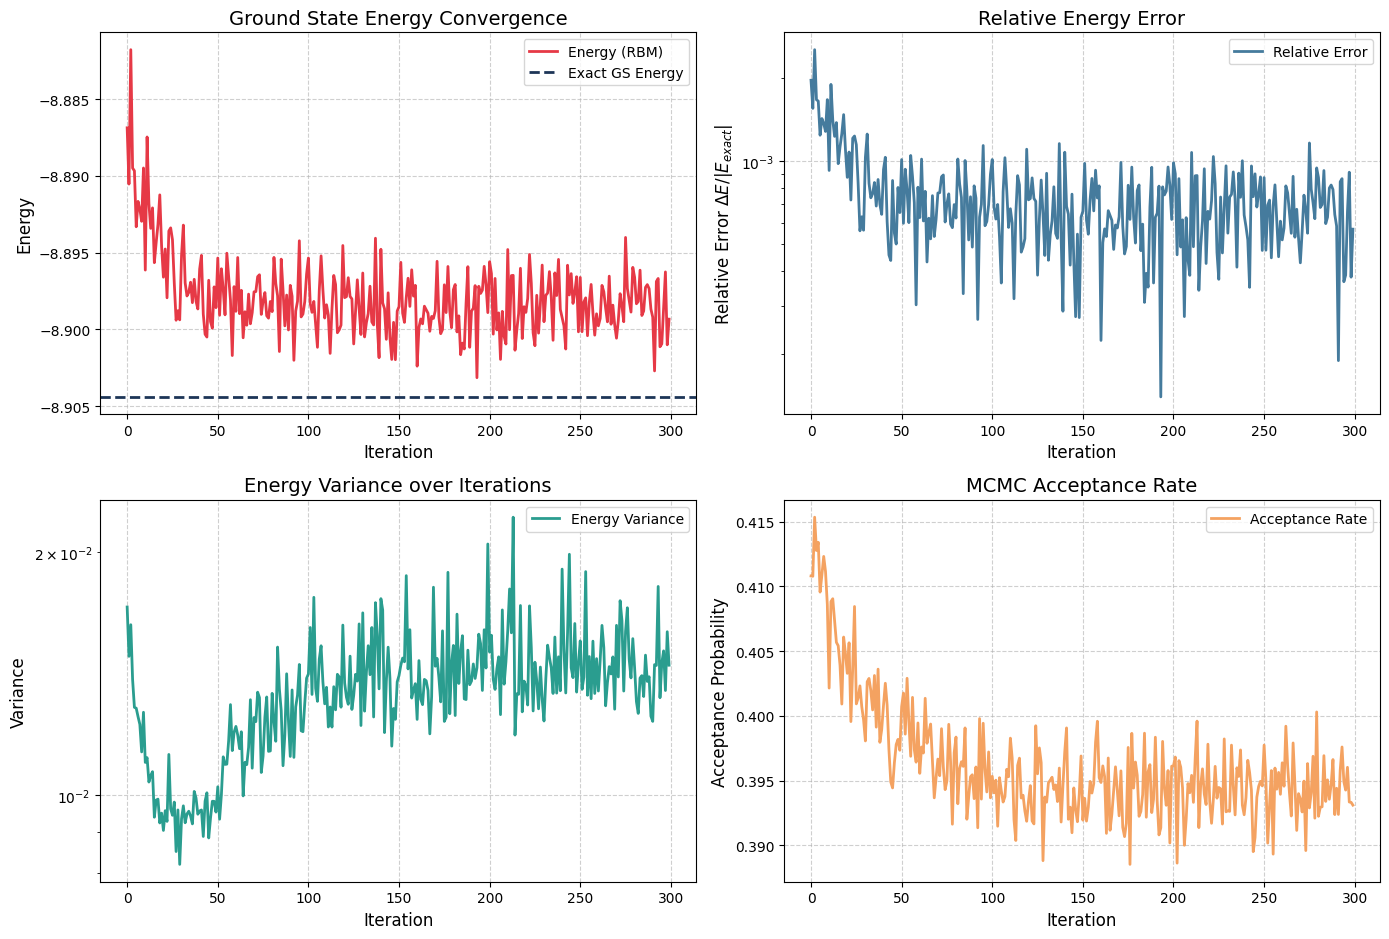

In [16]:
with open(data_file + "/RBM_alpha.log") as f:
    data = json.load(f)
    
iters_RBM = np.array(data["Energy"]["iters"])
energy_RBM = np.array(data["Energy"]["Mean"]["real"])
variance_RBM = np.array(data["Energy"]["Variance"])
acceptance_RBM = np.array(data["acceptance"]["value"])

relative_error = np.abs(energy_RBM - exact_gs_energy) / np.abs(exact_gs_energy)

print(f" -> Énergie moeynne Lancoz           : {np.mean(energy_RBM[100:]):.6f}")
print(f" -> Énergie exacte                   : {exact_gs_energy:.6f}")

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
# fig.suptitle("Optimization Metrics", fontsize=18, fontweight='bold', y=0.96)

# Modern color palette
colors = {
    "energy": "#e63946",    # Red
    "exact": "#1d3557",     # Dark Blue
    "error": "#457b9d",     # Steel Blue
    "variance": "#2a9d8f",  # Teal
    "accept": "#f4a261"     # Orange
}

# --- Top Left: Energy Optimization ---
axs[0, 0].plot(iters_RBM, energy_RBM, color=colors["energy"], linewidth=2, label="Energy (RBM)")
axs[0, 0].axhline(y=exact_gs_energy, color=colors["exact"], linestyle="--", linewidth=2, label="Exact GS Energy")
axs[0, 0].set_title("Ground State Energy Convergence", fontsize=14)
axs[0, 0].set_xlabel("Iteration", fontsize=12)
axs[0, 0].set_ylabel("Energy", fontsize=12)
axs[0, 0].legend(loc="upper right")

# --- Top Right: Relative Error (Log Scale) ---
axs[0, 1].semilogy(iters_RBM, relative_error, color=colors["error"], linewidth=2, label="Relative Error")
axs[0, 1].set_title("Relative Energy Error", fontsize=14)
axs[0, 1].set_xlabel("Iteration", fontsize=12)
axs[0, 1].set_ylabel(r"Relative Error $\Delta E / |E_{exact}|$", fontsize=12)
axs[0, 1].legend(loc="upper right")

# --- Bottom Left: Energy Variance ---
axs[1, 0].plot(iters_RBM, variance_RBM, color=colors["variance"], linewidth=2, label="Energy Variance")
axs[1, 0].set_title("Energy Variance over Iterations", fontsize=14)
axs[1, 0].set_xlabel("Iteration", fontsize=12)
axs[1, 0].set_ylabel("Variance", fontsize=12)
axs[1, 0].set_yscale("log") # Variance often spans multiple magnitudes
axs[1, 0].legend(loc="upper right")

# --- Bottom Right: Acceptance Rate ---
axs[1, 1].plot(iters_RBM, acceptance_RBM, color=colors["accept"], linewidth=2, label="Acceptance Rate")
axs[1, 1].set_title("MCMC Acceptance Rate", fontsize=14)
axs[1, 1].set_xlabel("Iteration", fontsize=12)
axs[1, 1].set_ylabel("Acceptance Probability", fontsize=12)
axs[1, 1].legend(loc="upper right")

# --- Final Adjustments ---
for ax in axs.flat:
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make room for suptitle
plt.savefig(data_file + "/VMC_optimization_metrics.png", dpi=300) # Save the figure
plt.show()

✅ Figure saved as ./datas/datas_alpha_J1_J2_0.0_iter_100/VMC_Sequential_metrics.png


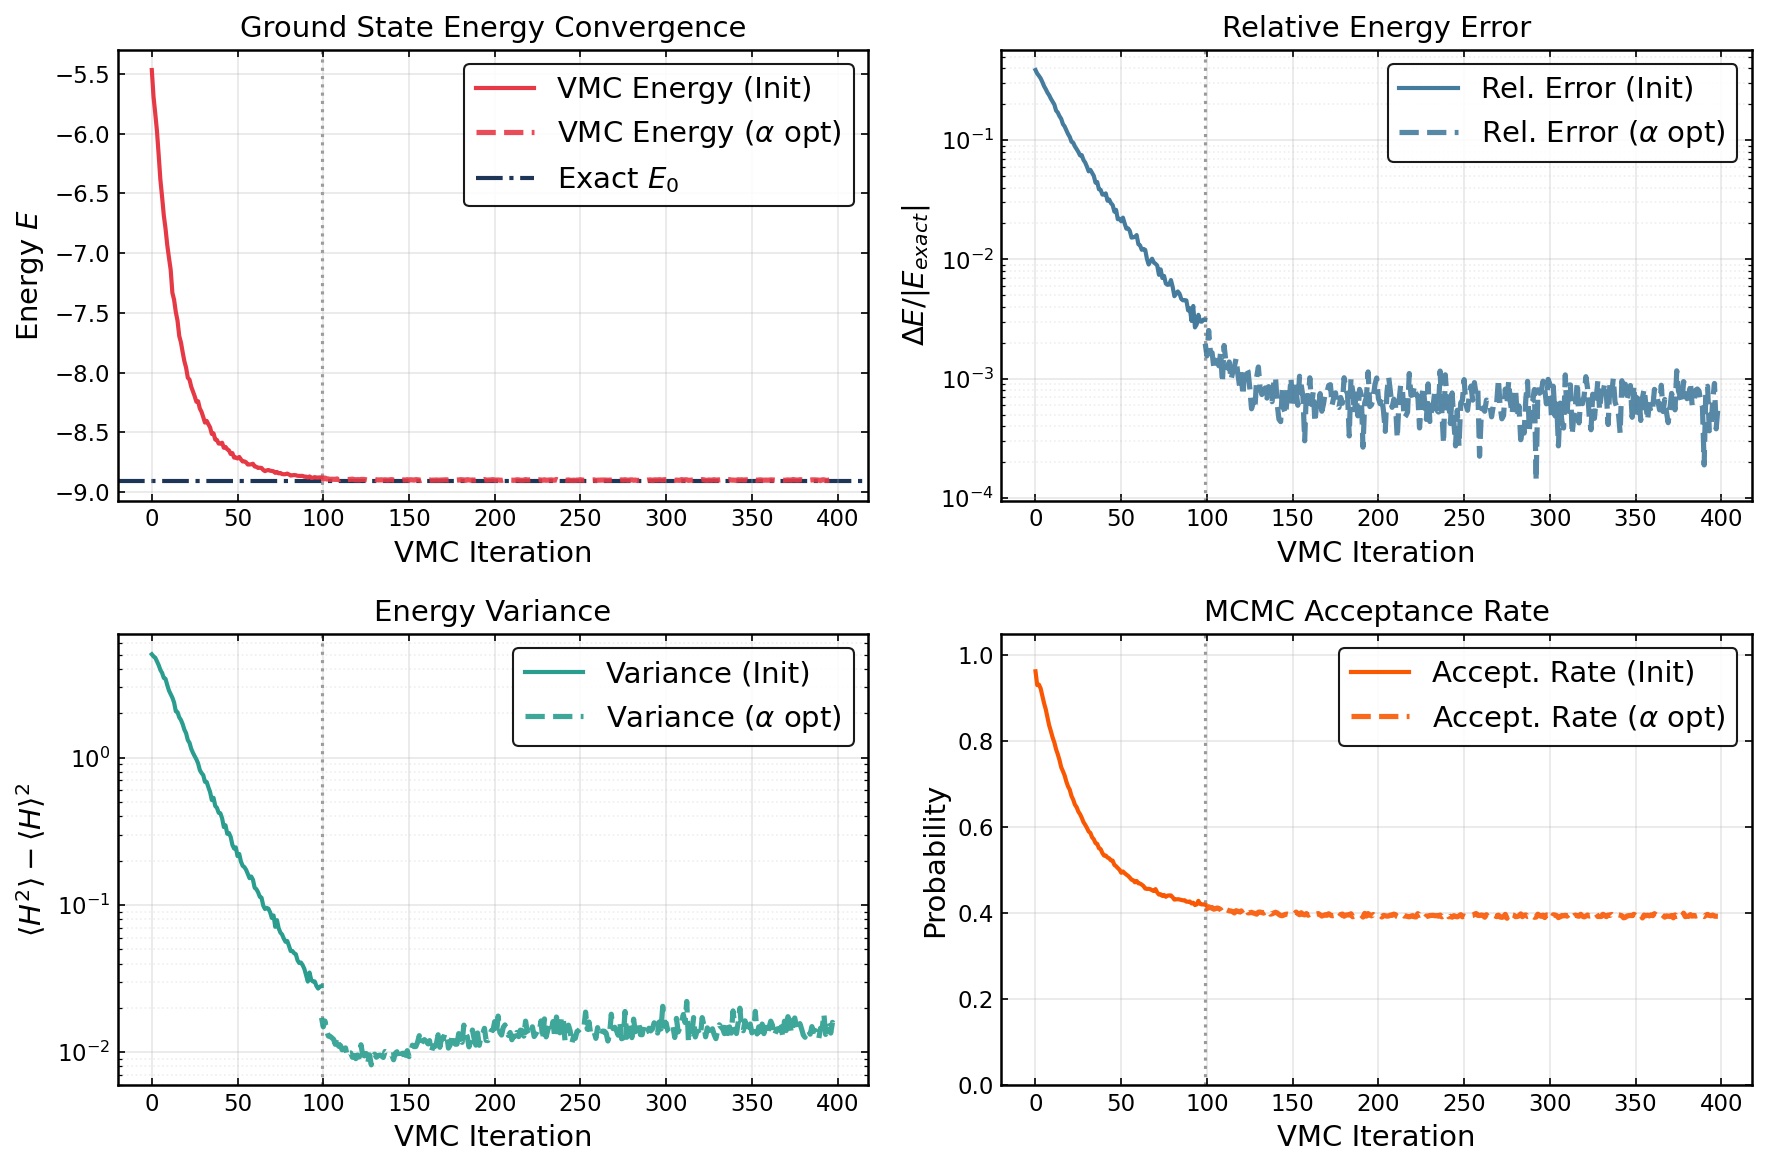

In [18]:
if verbose:
    file_init = f"{data_file}/VMC_datas.log"
    file_alpha = f"{data_file}/RBM_alpha.log"
    
    plot_VMC_sequential(
        data_file_init=file_init,
        data_file_alpha=file_alpha,
        exact_gs_energy=exact_gs_energy,
        save_fig=True,
        fig_name=f"{data_file}/VMC_Sequential_metrics.png"
    )

 -> Target Bootstrap Alpha : 0.130615 ± 0.000506
 -> Optimized VMC Alpha    : 0.132436 ± 0.000104 (last 100 iters)


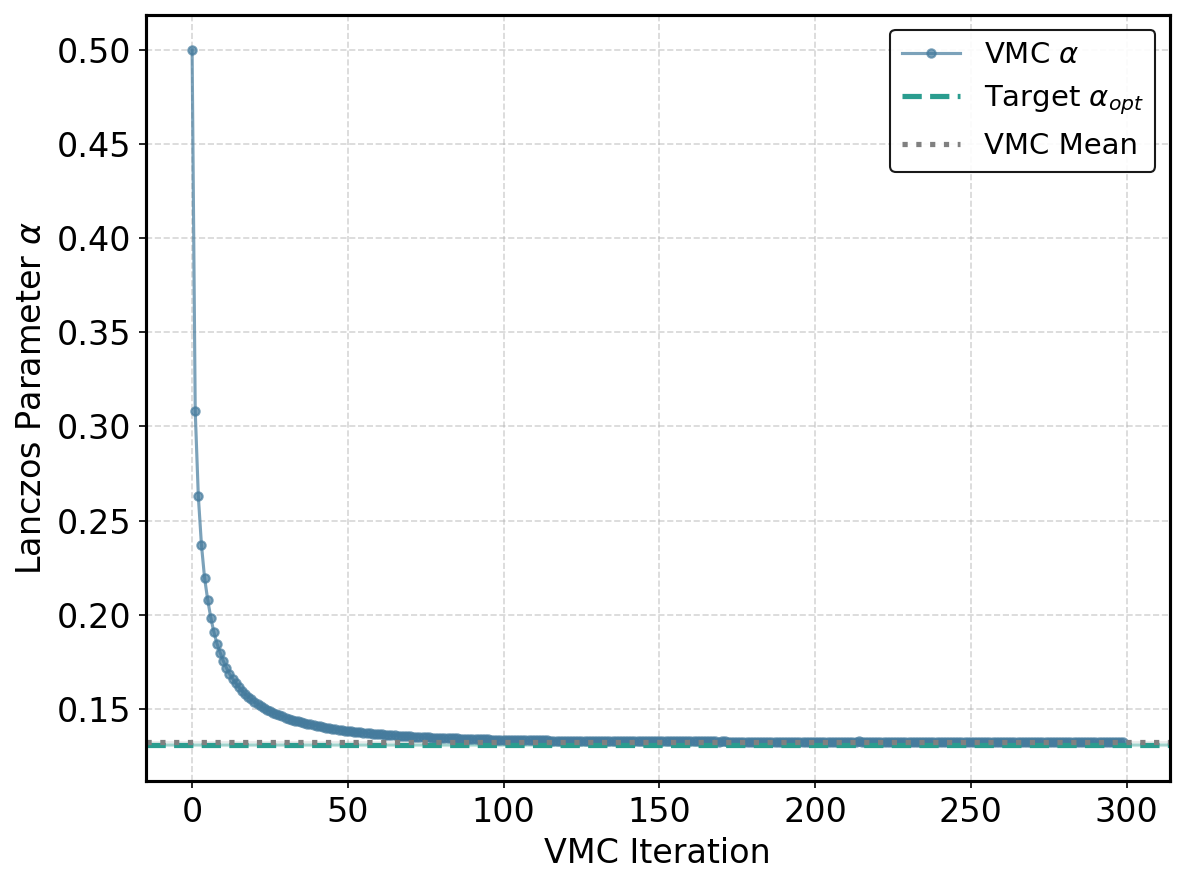

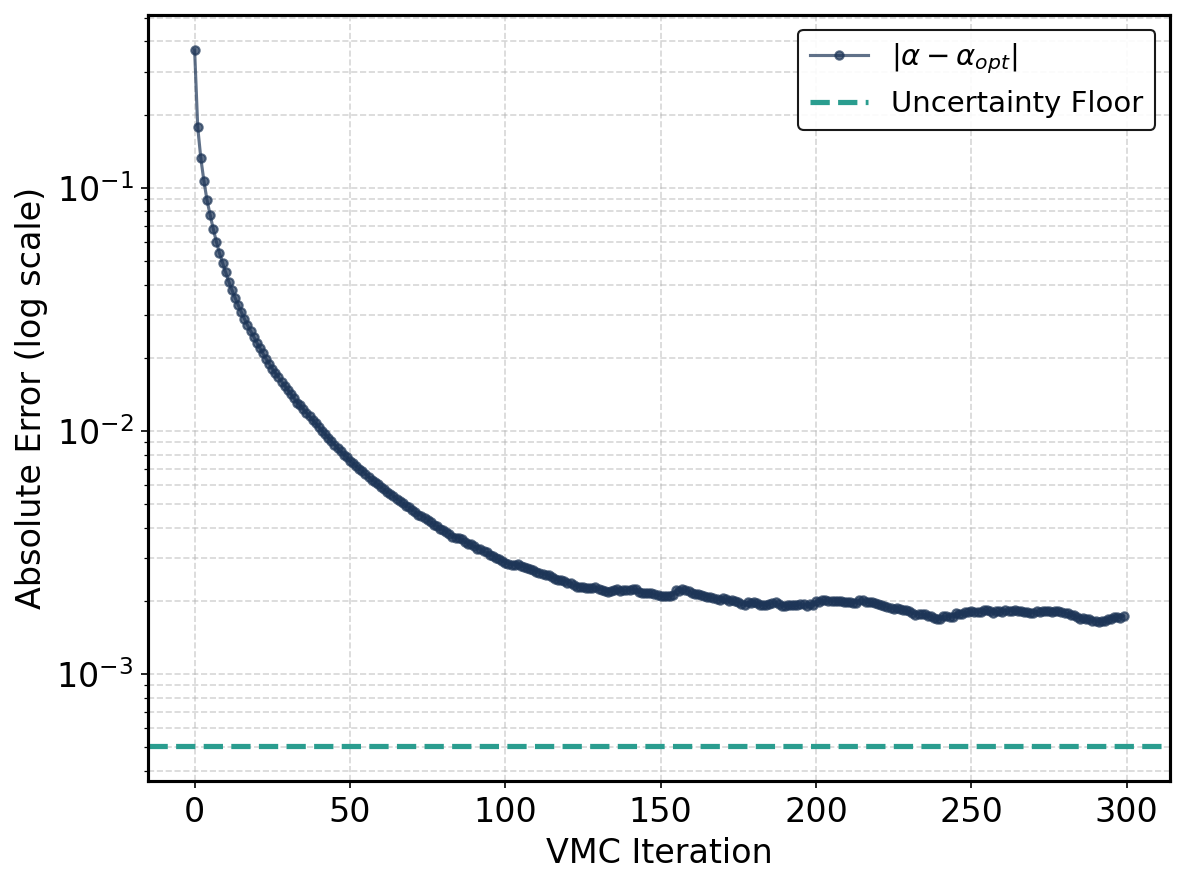

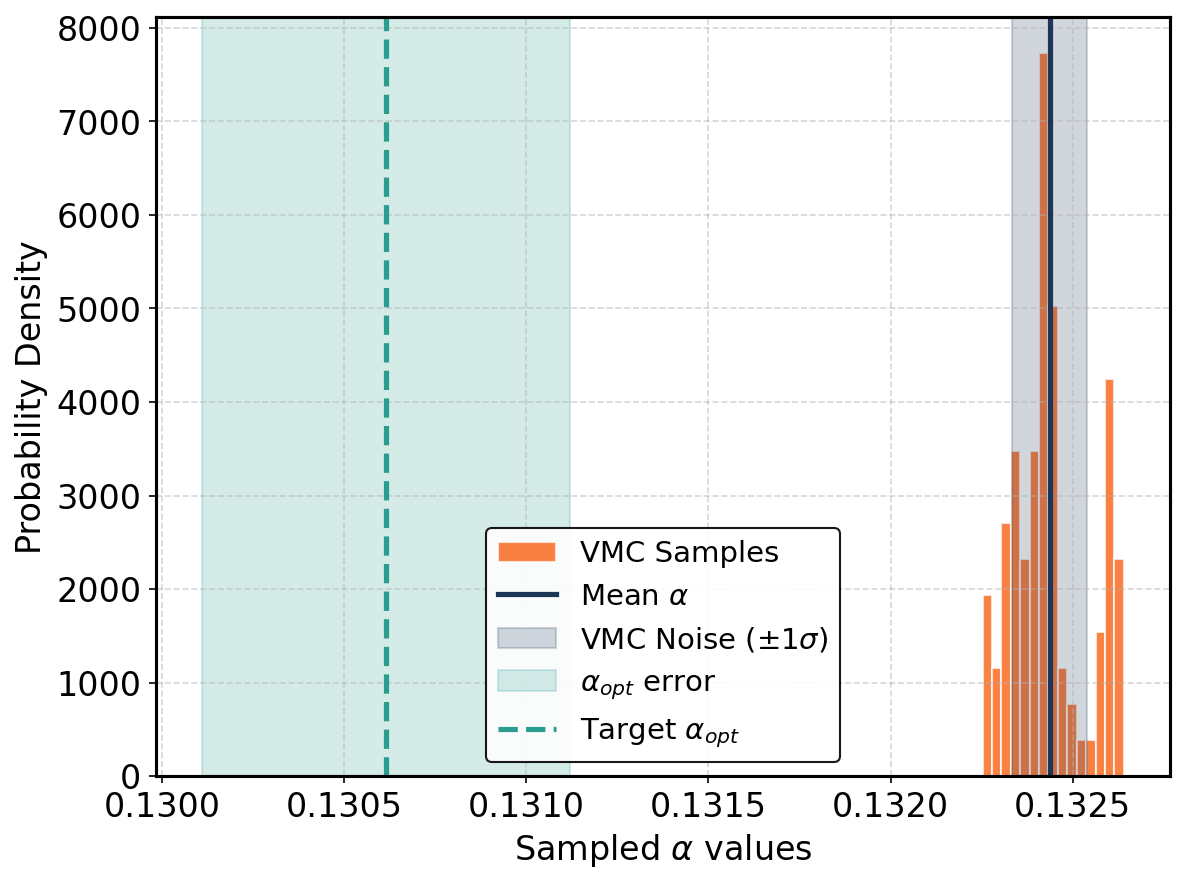

(np.float64(0.13243644226022877), np.float64(0.00010408091270639343))

In [19]:
plot_alpha_convergence(
    historique_alpha, 
    alpha_min=bootstrap_results["alpha_opt_final"], 
    alpha_err=bootstrap_results["alpha_opt_err"]
)

In [20]:
h2 = ha @ ha

results_eL = np.zeros(num_it)
results_e0 = np.zeros(num_it)
results_sigma_e0 = np.zeros(num_it) 
results_sigma_eL = np.zeros(num_it)
results_time = np.zeros(num_it) 

pbar = tqdm(range(num_it), desc="Monte Carlo Sampling")

start_time_global = time.perf_counter()

for i in pbar:

    vs_init.sample() 
    E_loc = vs_init.local_estimators(ha).real
    H2_loc = vs_init.local_estimators(h2).real
    e0 = jnp.mean(E_loc)
    sigma_e0 = jnp.mean(H2_loc) - e0**2

    vstate_lanczos.sample()
    E_loc_lan = vstate_lanczos.local_estimators(ha).real
    H2_loc_lan = vstate_lanczos.local_estimators(h2).real
    eL = jnp.mean(E_loc_lan)
    sigma_eL = jnp.mean(H2_loc_lan) - eL**2

    elapsed_time = time.perf_counter() - start_time_global

    results_e0[i] = e0.item()
    results_sigma_e0[i] = sigma_e0.item()
    results_eL[i] = eL.item()
    results_sigma_eL[i] = sigma_eL.item()
    results_time[i] = elapsed_time
    
    pbar.set_postfix(
        E0=f"{e0.item():.4f}", 
        EL=f"{eL.item():.4f}"
    )

Monte Carlo Sampling:   2%|▏         | 20/1000 [34:15<27:24:07, 100.66s/it, E0=-8.8760, EL=-8.8972]

In [ ]:
if verbose:
    print(f" -> Énergie moyenne VMC : {np.mean(results_e0):.6f} ± {np.std(results_e0):.6f}")
    print(f" -> Énergie moyenne Lanczos : {np.mean(results_eL):.6f} ± {np.std(results_eL):.6f}")

save_simulation_logs(
    target_dir=data_file,
    n_iterations=num_it,          
    e0_array=results_e0,      
    sigma_e0_array=results_sigma_e0, 
    el_array=results_eL,         
    sigma_el_array=results_sigma_eL,
    time_array=results_time,
    exact_energy=exact_gs_energy
)

 -> Énergie moyenne VMC : -0.062165 ± 0.740414
 -> Énergie moyenne Lanczos : -0.053392 ± 0.687216
Simulation logs successfully saved to: ./datas/datas_alpha_J1_J2_0.0_iter_100/simulation_results.json


Graphique sauvegardé sous : ./datas/datas_alpha_J1_J2_0.0_iter_100/distribution_energies_krylov.png


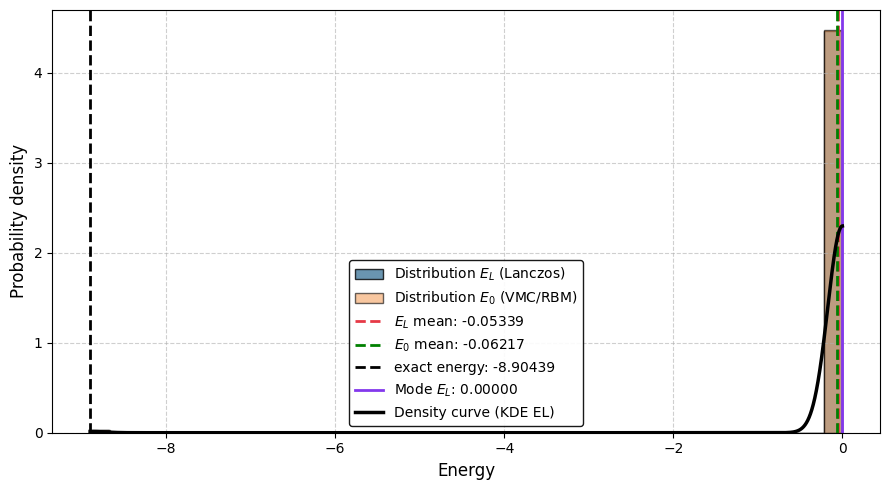

In [ ]:
plot_energy_distribution(
    el_valides=results_eL, 
    results_e0=results_e0, 
    exact_gs_energy=exact_gs_energy, 
    data_file=data_file,
    bins=40 
)

Graphique d'extrapolation sauvegardé sous : ./datas/datas_alpha_J1_J2_0.0_iter_100/extrapolation_plot.png


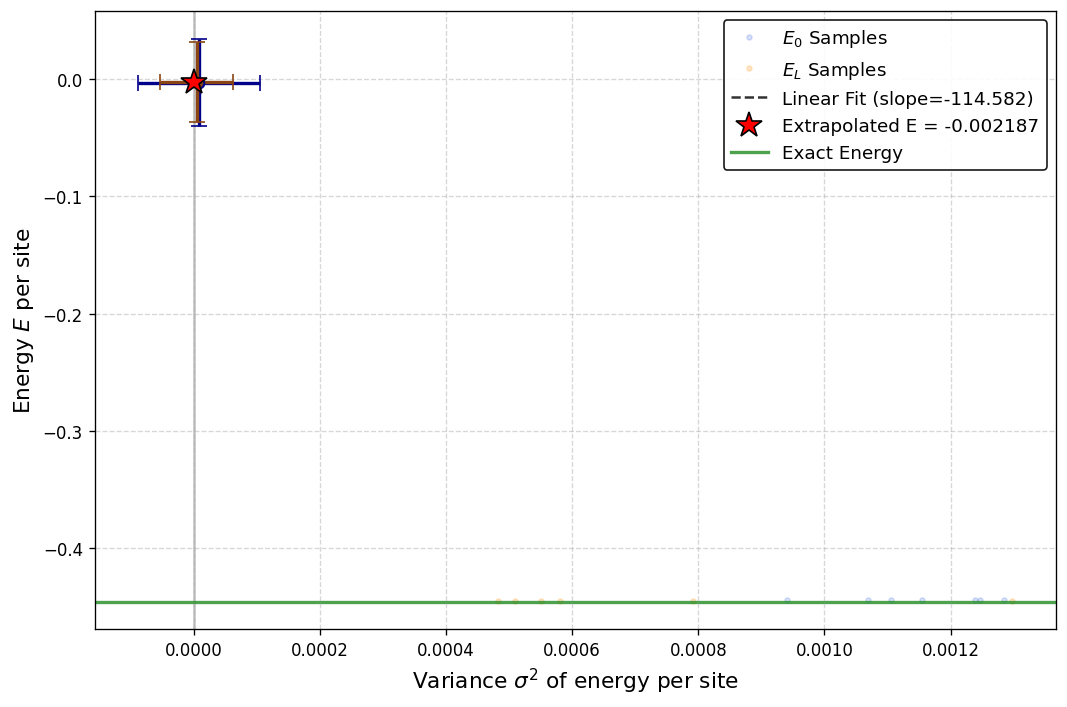


--- Extrapolation Results (per site) ---
Extrapolated Energy (x=0) : -0.00218706
Exact Energy              : -0.44521933
Absolute Error            : 4.43032264e-01
----------------------------------------



In [ ]:
plot_zero_variance_extrapolation(
    results_e0 = results_e0, 
    results_sigma_e0 = results_sigma_e0, 
    el_valides = results_eL, 
    results_sigma_eL = results_sigma_eL, 
    exact_gs_energy = exact_gs_energy, 
    L = L, 
    data_file = data_file
)